# Training-results analysis

This notebook analyzes every metrics CSV under `runs/results`. It focuses on model-selection tradeoffs, especially the minority `pollenbee` class, rather than selecting a checkpoint from aggregate mAP alone.

The fixed-threshold precision, recall, and F1 values use the confidence and IoU thresholds recorded in each CSV row. They are not directly interchangeable with AP, which is calculated from ranked detections.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (12, 5), "axes.titlesize": 12})

## Load and validate result files

The repository root is detected so this notebook works when launched from either the repository root or the `analysis` directory.

In [2]:
def find_repo_root(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "runs" / "results").is_dir():
            return candidate
    raise FileNotFoundError("Could not find a parent containing runs/results")


repo_root = find_repo_root()
results_dir = repo_root / "runs" / "results"
result_files = sorted(results_dir.glob("*.csv"))
if not result_files:
    raise FileNotFoundError(f"No CSV result files found in {results_dir}")

frames = []
for path in result_files:
    frame = pd.read_csv(path, dtype={"run_id": "string", "model_name": "string"})
    frame["source_file"] = path.name
    frames.append(frame)

results = pd.concat(frames, ignore_index=True)
source_columns = list(results.columns)
required_columns = {
    "epoch", "train_loss", "map_50", "map_50_95", "stats_conf_thr", "stats_iou_thr",
    "nonpollenbee_precision", "nonpollenbee_recall", "nonpollenbee_f1",
    "nonpollenbee_tp", "nonpollenbee_fp", "nonpollenbee_fn",
    "pollenbee_precision", "pollenbee_recall", "pollenbee_f1",
    "pollenbee_tp", "pollenbee_fp", "pollenbee_fn",
}
missing_columns = sorted(required_columns.difference(results.columns))
if missing_columns:
    raise ValueError(f"Missing required result columns: {missing_columns}")

results = results.sort_values(["source_file", "epoch"]).reset_index(drop=True)
print(f"Loaded {len(results):,} epoch rows from {len(result_files)} result file(s).")
display(results.head())

Loaded 75 epoch rows from 1 result file(s).


,run_id,model_name,epoch,lr,train_loss,map_50,map_50_95,stats_conf_thr,stats_iou_thr,nonpollenbee_precision,nonpollenbee_recall,nonpollenbee_f1,nonpollenbee_tp,nonpollenbee_fp,nonpollenbee_fn,pollenbee_precision,pollenbee_recall,pollenbee_f1,pollenbee_tp,pollenbee_fp,pollenbee_fn,source_file
0,20260604_231514,custom_yolov8s_baseline,1,0.0100,7.4233,0.0053,-1.0000,0.2500,0.5000,0.0000,0.0000,0.0000,0,0,10796,0.0000,0.0000,0.0000,0,0,307,custom_yolov8s_baseline_20260604_231514.csv
1,20260604_231514,custom_yolov8s_baseline,2,0.0100,3.0483,0.6605,-1.0000,0.2500,0.5000,0.7758,0.8870,0.8277,9576,2768,1220,0.1547,0.6450,0.2495,198,1082,109,custom_yolov8s_baseline_20260604_231514.csv
2,20260604_231514,custom_yolov8s_baseline,3,0.0100,2.6809,0.8010,-1.0000,0.2500,0.5000,0.6892,0.9662,0.8045,10431,4705,365,0.1528,0.8534,0.2591,262,1453,45,custom_yolov8s_baseline_20260604_231514.csv
3,20260604_231514,custom_yolov8s_baseline,4,0.0100,2.4752,0.8119,-1.0000,0.2500,0.5000,0.6675,0.9685,0.7903,10456,5208,340,0.1504,0.8762,0.2567,269,1520,38,custom_yolov8s_baseline_20260604_231514.csv
4,20260604_231514,custom_yolov8s_baseline,5,0.0100,2.3513,0.8643,-1.0000,0.2500,0.5000,0.7796,0.9763,0.8670,10540,2979,256,0.2028,0.9121,0.3318,280,1101,27,custom_yolov8s_baseline_20260604_231514.csv


In [3]:
results["macro_precision"] = results[["nonpollenbee_precision", "pollenbee_precision"]].mean(axis=1)
results["macro_recall"] = results[["nonpollenbee_recall", "pollenbee_recall"]].mean(axis=1)
results["macro_f1"] = results[["nonpollenbee_f1", "pollenbee_f1"]].mean(axis=1)
results["nonpollenbee_support"] = results["nonpollenbee_tp"] + results["nonpollenbee_fn"]
results["pollenbee_support"] = results["pollenbee_tp"] + results["pollenbee_fn"]
results["support_ratio"] = results["nonpollenbee_support"] / results["pollenbee_support"].replace(0, np.nan)
results["map_50_95_valid"] = results["map_50_95"].where(results["map_50_95"] >= 0)

inventory = (
    results.groupby("source_file", as_index=False)
    .agg(
        model_name=("model_name", "first"),
        run_id=("run_id", "first"),
        first_epoch=("epoch", "min"),
        last_epoch=("epoch", "max"),
        rows=("epoch", "size"),
        confidence_threshold=("stats_conf_thr", "first"),
        stats_iou_threshold=("stats_iou_thr", "first"),
    )
)
display(inventory)

,source_file,model_name,run_id,first_epoch,last_epoch,rows,confidence_threshold,stats_iou_threshold
0,custom_yolov8s_baseline_20260604_231514.csv,custom_yolov8s_baseline,20260604_231514,1,75,75,0.2500,0.5000


## Data-quality checks

`torchmetrics` uses `-1` as a sentinel when a metric is unavailable. These values must be excluded rather than interpreted as real AP scores. In this run, the full-range aggregate AP is invalid because evaluation requests `max_detection_thresholds=[1, 10, 300]`, while pycocotools' aggregate AP summary looks for its default `maxDets=100`. Use standard `maxDets=100` or calculate the `maxDets=300` aggregate explicitly.

In [4]:
quality_checks = pd.Series({
    "result files": len(result_files),
    "epoch rows": len(results),
    "duplicate file/epoch rows": int(results.duplicated(["source_file", "epoch"]).sum()),
    "rows with any missing source value": int(results[source_columns].isna().any(axis=1).sum()),
    "invalid mAP@0.50:0.95 rows": int(results["map_50_95"].lt(0).sum()),
    "valid mAP@0.50:0.95 rows": int(results["map_50_95_valid"].notna().sum()),
})
display(quality_checks.to_frame("value"))

if results["map_50_95_valid"].notna().sum() == 0:
    warnings.warn(
        "All mAP@0.50:0.95 values are -1, so that metric is unavailable and excluded from analysis. "
        "Investigate evaluation before reporting it."
    )

per_class_ap_columns = [column for column in results.columns if "ap" in column.lower() and "map" not in column.lower()]
if not per_class_ap_columns:
    warnings.warn("The CSVs contain no per-class AP columns; class-level AP cannot be analyzed from runs/results.")

,value
result files,1
epoch rows,75
duplicate file/epoch rows,0
rows with any missing value,75
invalid mAP@0.50:0.95 rows,75
valid mAP@0.50:0.95 rows,0


C:\Users\ASUS\AppData\Local\Temp\ipykernel_14236\2766433388.py:12: UserWarning: All mAP@0.50:0.95 values are -1, so that metric is unavailable and excluded from analysis. Investigate evaluation before reporting it.
  warnings.warn(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14236\2766433388.py:19: UserWarning: The CSVs contain no per-class AP columns; class-level AP cannot be analyzed from runs/results.
  warnings.warn("The CSVs contain no per-class AP columns; class-level AP cannot be analyzed from runs/results.")


## Run summary and checkpoint candidates

Three checkpoint objectives are compared:

- **best mAP@0.50**: appropriate when the aggregate ranked-detection metric is the primary objective.
- **best pollenbee F1**: appropriate when minority-class fixed-threshold performance is the priority.
- **best macro F1**: gives both classes equal weight and is the strongest default for balanced fixed-threshold deployment.

In [5]:
summary_rows = []
candidate_rows = []

for source_file, run in results.groupby("source_file", sort=False):
    run = run.sort_values("epoch")
    best_map = run.loc[run["map_50"].idxmax()]
    best_pollenbee = run.loc[run["pollenbee_f1"].idxmax()]
    best_macro = run.loc[run["macro_f1"].idxmax()]
    final = run.iloc[-1]

    summary_rows.append({
        "source_file": source_file,
        "model_name": final["model_name"],
        "epochs": len(run),
        "nonpollenbee_support": int(final["nonpollenbee_support"]),
        "pollenbee_support": int(final["pollenbee_support"]),
        "support_ratio": final["support_ratio"],
        "best_map_50": best_map["map_50"],
        "best_map_epoch": int(best_map["epoch"]),
        "best_pollenbee_f1": best_pollenbee["pollenbee_f1"],
        "best_pollenbee_f1_epoch": int(best_pollenbee["epoch"]),
        "best_macro_f1": best_macro["macro_f1"],
        "best_macro_f1_epoch": int(best_macro["epoch"]),
        "final_map_50": final["map_50"],
        "final_pollenbee_f1": final["pollenbee_f1"],
        "final_macro_f1": final["macro_f1"],
    })

    for objective, row in [
        ("best mAP@0.50", best_map),
        ("best pollenbee F1", best_pollenbee),
        ("best macro F1", best_macro),
        ("final epoch", final),
    ]:
        candidate_rows.append({
            "source_file": source_file,
            "objective": objective,
            "epoch": int(row["epoch"]),
            "train_loss": row["train_loss"],
            "map_50": row["map_50"],
            "nonpollenbee_f1": row["nonpollenbee_f1"],
            "pollenbee_precision": row["pollenbee_precision"],
            "pollenbee_recall": row["pollenbee_recall"],
            "pollenbee_f1": row["pollenbee_f1"],
            "macro_f1": row["macro_f1"],
            "pollenbee_fp": int(row["pollenbee_fp"]),
            "pollenbee_fn": int(row["pollenbee_fn"]),
        })

run_summary = pd.DataFrame(summary_rows)
checkpoint_candidates = pd.DataFrame(candidate_rows)
display(run_summary)
display(checkpoint_candidates)

,source_file,model_name,epochs,nonpollenbee_support,pollenbee_support,support_ratio,best_map_50,best_map_epoch,best_pollenbee_f1,best_pollenbee_f1_epoch,best_macro_f1,best_macro_f1_epoch,final_map_50,final_pollenbee_f1,final_macro_f1
0,custom_yolov8s_baseline_20260604_231514.csv,custom_yolov8s_baseline,75,10796,307,35.1661,0.9474,16,0.8536,23,0.9051,62,0.9414,0.8069,0.8898


,source_file,objective,epoch,train_loss,map_50,nonpollenbee_f1,pollenbee_precision,pollenbee_recall,pollenbee_f1,macro_f1,pollenbee_fp,pollenbee_fn
0,custom_yolov8s_baseline_20260604_231514.csv,best mAP@0.50,16,1.7502,0.9474,0.9324,0.3384,0.9511,0.4991,0.7158,571,15
1,custom_yolov8s_baseline_20260604_231514.csv,best pollenbee F1,23,1.5763,0.9363,0.9468,0.8099,0.9023,0.8536,0.9002,65,30
2,custom_yolov8s_baseline_20260604_231514.csv,best macro F1,62,1.1304,0.9424,0.9743,0.7713,0.9121,0.8358,0.9051,83,27
3,custom_yolov8s_baseline_20260604_231514.csv,final epoch,75,1.0389,0.9414,0.9728,0.7194,0.9186,0.8069,0.8898,110,25


## Training curves

The plots separate ranked-detection mAP from fixed-threshold class metrics. A stable mAP curve can coexist with volatile pollenbee precision and F1.

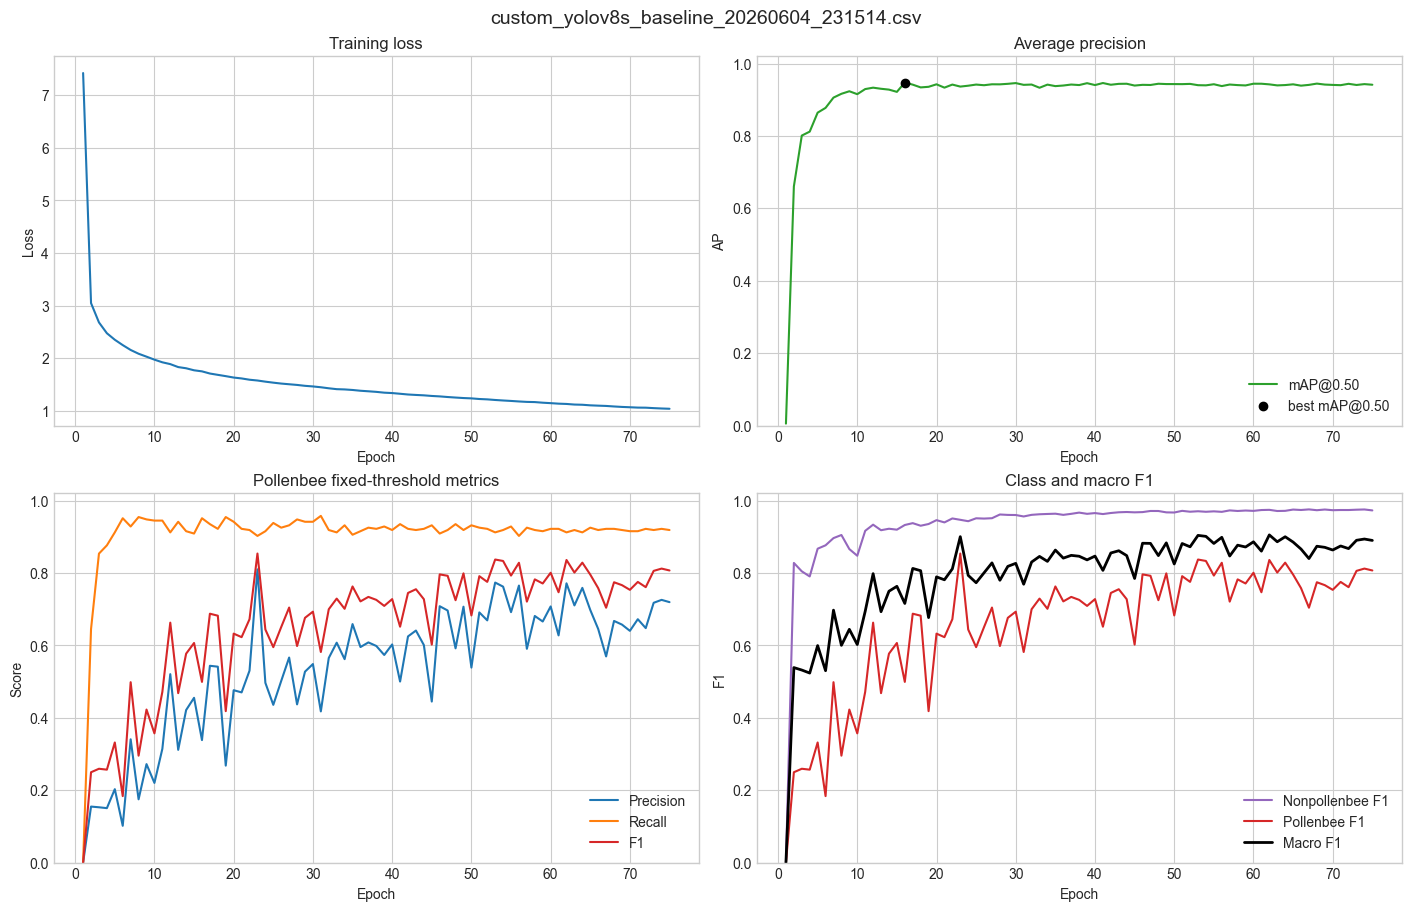

In [6]:
for source_file, run in results.groupby("source_file", sort=False):
    run = run.sort_values("epoch")
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
    fig.suptitle(source_file, fontsize=14)

    axes[0, 0].plot(run["epoch"], run["train_loss"], color="tab:blue")
    axes[0, 0].set(title="Training loss", xlabel="Epoch", ylabel="Loss")

    axes[0, 1].plot(run["epoch"], run["map_50"], label="mAP@0.50", color="tab:green")
    if run["map_50_95_valid"].notna().any():
        axes[0, 1].plot(run["epoch"], run["map_50_95_valid"], label="mAP@0.50:0.95", color="tab:olive")
    best_map = run.loc[run["map_50"].idxmax()]
    axes[0, 1].scatter(best_map["epoch"], best_map["map_50"], color="black", zorder=3, label="best mAP@0.50")
    axes[0, 1].set(title="Average precision", xlabel="Epoch", ylabel="AP", ylim=(0, 1.02))
    axes[0, 1].legend()

    for metric, label, color in [
        ("pollenbee_precision", "Precision", "tab:blue"),
        ("pollenbee_recall", "Recall", "tab:orange"),
        ("pollenbee_f1", "F1", "tab:red"),
    ]:
        axes[1, 0].plot(run["epoch"], run[metric], label=label, color=color)
    axes[1, 0].set(title="Pollenbee fixed-threshold metrics", xlabel="Epoch", ylabel="Score", ylim=(0, 1.02))
    axes[1, 0].legend()

    axes[1, 1].plot(run["epoch"], run["nonpollenbee_f1"], label="Nonpollenbee F1", color="tab:purple")
    axes[1, 1].plot(run["epoch"], run["pollenbee_f1"], label="Pollenbee F1", color="tab:red")
    axes[1, 1].plot(run["epoch"], run["macro_f1"], label="Macro F1", color="black", linewidth=2)
    axes[1, 1].set(title="Class and macro F1", xlabel="Epoch", ylabel="F1", ylim=(0, 1.02))
    axes[1, 1].legend()

    plt.show()

## Minority-class errors and late-training stability

Pollenbee false positives explain much of the F1 volatility. The stability table summarizes the last 10 epochs of each run.

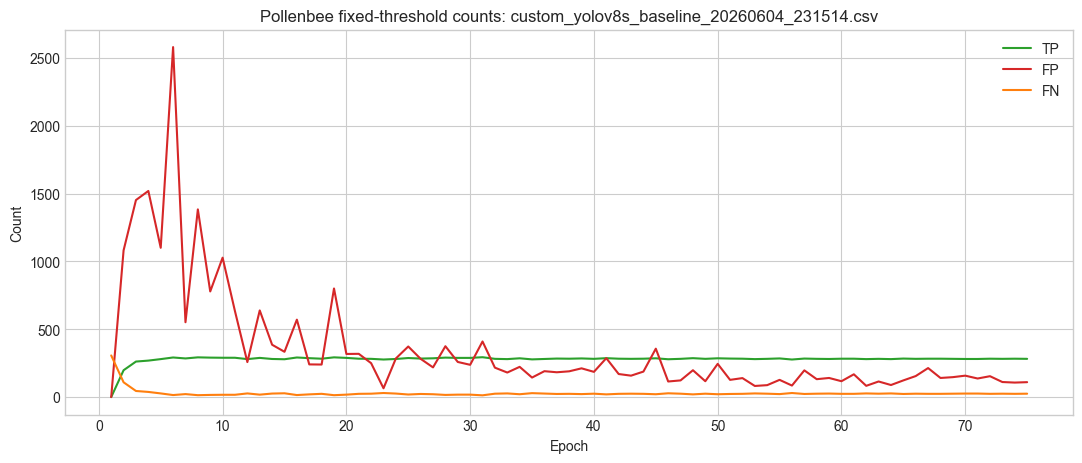

,source_file,last_n_epochs,map_50_mean,map_50_std,pollenbee_f1_mean,pollenbee_f1_std,nonpollenbee_f1_mean,nonpollenbee_f1_std,best_to_final_map_50_gap
0,custom_yolov8s_baseline_20260604_231514.csv,10,0.9416,0.0018,0.7717,0.0321,0.9742,0.0010,0.0061


In [7]:
for source_file, run in results.groupby("source_file", sort=False):
    run = run.sort_values("epoch")
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(run["epoch"], run["pollenbee_tp"], label="TP", color="tab:green")
    ax.plot(run["epoch"], run["pollenbee_fp"], label="FP", color="tab:red")
    ax.plot(run["epoch"], run["pollenbee_fn"], label="FN", color="tab:orange")
    ax.set(title=f"Pollenbee fixed-threshold counts: {source_file}", xlabel="Epoch", ylabel="Count")
    ax.legend()
    plt.show()

stability_rows = []
for source_file, run in results.groupby("source_file", sort=False):
    run = run.sort_values("epoch")
    tail = run.tail(10)
    stability_rows.append({
        "source_file": source_file,
        "last_n_epochs": len(tail),
        "map_50_mean": tail["map_50"].mean(),
        "map_50_std": tail["map_50"].std(),
        "pollenbee_f1_mean": tail["pollenbee_f1"].mean(),
        "pollenbee_f1_std": tail["pollenbee_f1"].std(),
        "nonpollenbee_f1_mean": tail["nonpollenbee_f1"].mean(),
        "nonpollenbee_f1_std": tail["nonpollenbee_f1"].std(),
        "best_to_final_map_50_gap": run["map_50"].max() - run.iloc[-1]["map_50"],
    })

stability = pd.DataFrame(stability_rows)
display(stability)

## Current baseline interpretation

For `custom_yolov8s_baseline_20260604_231514.csv`:

- The validation support is **10,796 nonpollenbee vs 307 pollenbee instances**, a **35.2:1 imbalance**. Minority-class metrics therefore deserve explicit checkpoint selection and reporting.
- **Epoch 16** has the best `mAP@0.50` (**0.9474**), but its pollenbee F1 is only **0.4991** because pollenbee precision is **0.3384** with **571 false positives**. It is not the best fixed-threshold deployment checkpoint.
- **Epoch 23** has the best pollenbee F1 (**0.8536**) with precision **0.8099**, recall **0.9023**, and only **65 pollenbee false positives**. Choose it when pollenbee F1 is the primary requirement.
- **Epoch 62** has the best macro F1 (**0.9051**) while retaining `mAP@0.50 = 0.9424` and pollenbee F1 **0.8358**. It is the strongest balanced default among the recorded epochs.
- The final epoch reaches `mAP@0.50 = 0.9414`, only **0.0061** below the best, but its macro F1 (**0.8898**) is below epoch 62. Continuing to epoch 75 did not improve the best deployment-oriented checkpoint.
- During the last 10 epochs, `mAP@0.50` is stable (standard deviation **0.0018**) while pollenbee F1 remains more volatile (standard deviation **0.0321**). This is mainly driven by changing pollenbee false-positive counts.
- Every `mAP@0.50:0.95` value is **-1**, so that metric is invalid and must not be reported from this CSV. The cause is the requested `maxDets=300`: pycocotools' aggregate AP summary defaults to `maxDets=100` and returns `-1` when 100 is absent. The CSV also lacks per-class AP, preventing direct analysis of class-level ranked-detection quality.

**Recommendation:** use epoch 62 as the balanced checkpoint, epoch 23 when pollenbee F1 is the overriding goal, and epoch 16 only when aggregate `mAP@0.50` is explicitly the selection criterion. Repair and rerun `mAP@0.50:0.95` evaluation before publication-quality reporting, either with standard `maxDets=100` or an explicit aggregate calculation at `maxDets=300`.

## Programmatic findings for future runs

This final cell regenerates the core conclusions when new CSV files are added.

In [8]:
for source_file, run in results.groupby("source_file", sort=False):
    run = run.sort_values("epoch")
    best_map = run.loc[run["map_50"].idxmax()]
    best_pollenbee = run.loc[run["pollenbee_f1"].idxmax()]
    best_macro = run.loc[run["macro_f1"].idxmax()]
    final = run.iloc[-1]

    print(f"\n{source_file}")
    print(f"  Support imbalance: {final['support_ratio']:.1f}:1 nonpollenbee:pollenbee")
    print(f"  Best mAP@0.50: epoch {int(best_map['epoch'])}, {best_map['map_50']:.4f}; pollenbee F1 {best_map['pollenbee_f1']:.4f}")
    print(f"  Best pollenbee F1: epoch {int(best_pollenbee['epoch'])}, {best_pollenbee['pollenbee_f1']:.4f}; mAP@0.50 {best_pollenbee['map_50']:.4f}")
    print(f"  Best macro F1: epoch {int(best_macro['epoch'])}, {best_macro['macro_f1']:.4f}; mAP@0.50 {best_macro['map_50']:.4f}")
    print(f"  Final epoch {int(final['epoch'])}: mAP@0.50 {final['map_50']:.4f}, pollenbee F1 {final['pollenbee_f1']:.4f}, macro F1 {final['macro_f1']:.4f}")
    if run["map_50_95_valid"].notna().sum() == 0:
        print("  WARNING: mAP@0.50:0.95 is unavailable for every epoch.")


custom_yolov8s_baseline_20260604_231514.csv
  Support imbalance: 35.2:1 nonpollenbee:pollenbee
  Best mAP@0.50: epoch 16, 0.9474; pollenbee F1 0.4991
  Best pollenbee F1: epoch 23, 0.8536; mAP@0.50 0.9363
  Best macro F1: epoch 62, 0.9051; mAP@0.50 0.9424
  Final epoch 75: mAP@0.50 0.9414, pollenbee F1 0.8069, macro F1 0.8898
